## Using SVD to reduce the order of the data from LHS on a flow over a cylinder case

In [202]:
import numpy as np 
import matplotlib.pyplot as plt 

# Loading data from the dat file obtained from PCE
Cd_data = np.loadtxt('pce_uq_results.dat', skiprows=1, usecols=range(6, 1204))
Cl_data = np.loadtxt('pce_uq_results.dat', skiprows=1, usecols=range(1206, 2404))
# The first four columns are eval_id, interface, x1, x2 
# making the data from each analysis a column vector
Cd_data = Cd_data.T
Cl_data = Cl_data.T

# printing the data to see what it looks like
print(Cd_data.shape)
print(Cl_data.shape)

(1198, 100)
(1198, 100)


### Plotting the analysis obtained from PCE

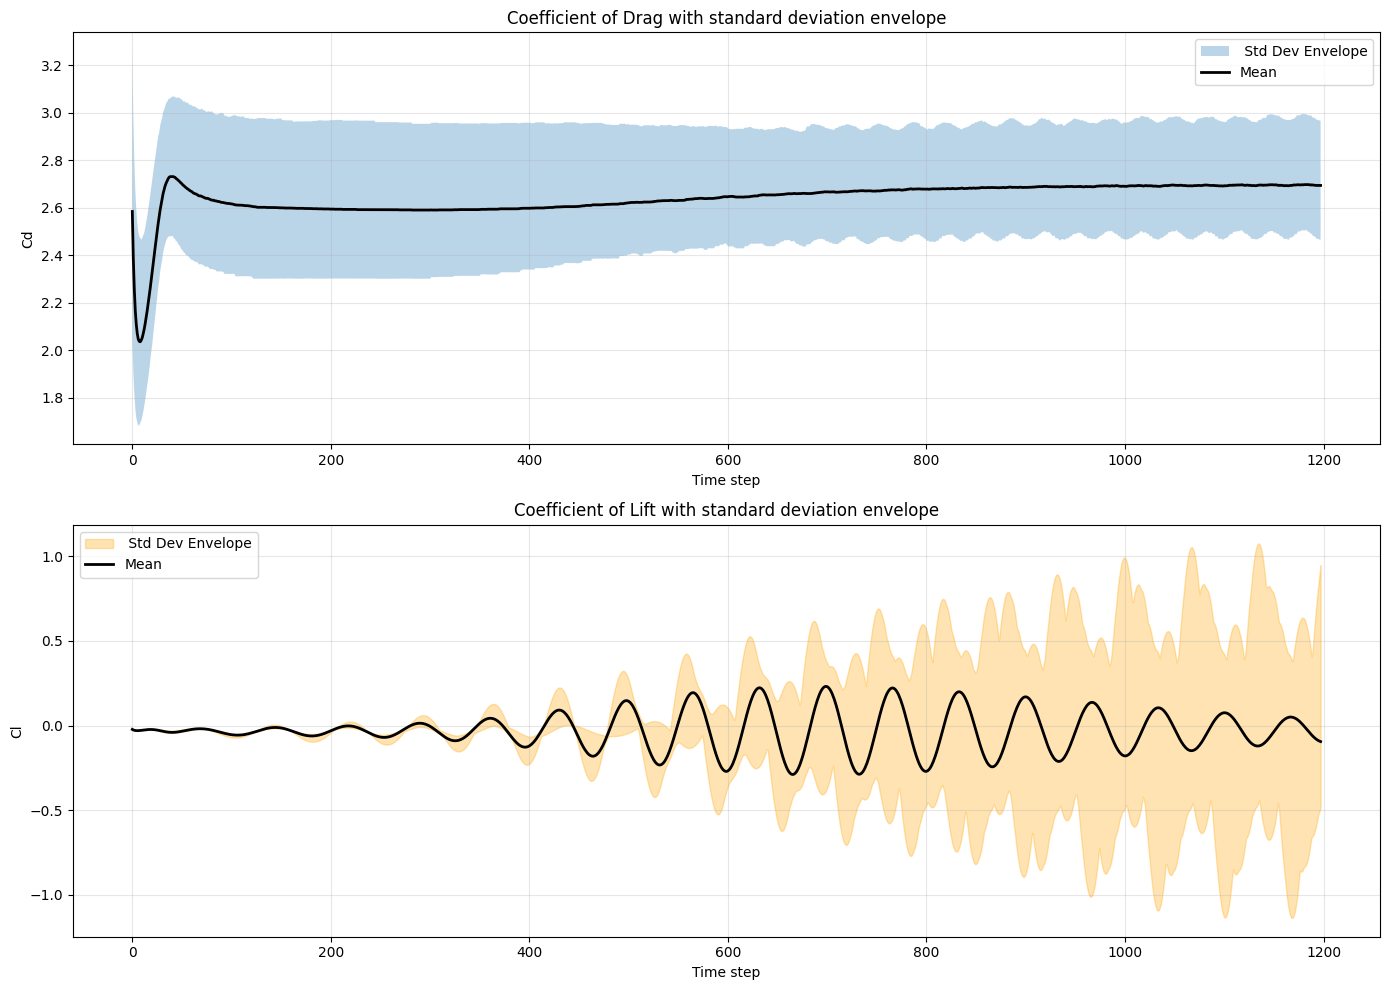

In [203]:
# For each time step, compute statistics across all 100 samples
mean_cd_full = Cd_data.mean(axis=1)  # Mean at each time step
std_cd_full = Cd_data.std(axis=1)    # Std dev at each time step
min_cd_full = Cd_data.min(axis=1)    # Min at each time step
max_cd_full = Cd_data.max(axis=1)    # Max at each time step
mean_cl_full = Cl_data.mean(axis=1)  # Mean at each time step
std_cl_full = Cl_data.std(axis=1)    # Std dev at each time step
min_cl_full = Cl_data.min(axis=1)    # Min at each time step
max_cl_full = Cl_data.max(axis=1)    # Max at each time step

# Plot these
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].fill_between(range(1198), min_cd_full, max_cd_full, alpha=0.3, label = ' Std Dev Envelope')
axes[0].plot(mean_cd_full, 'k-', linewidth=2, label='Mean')
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('Cd')
axes[0].set_title('Coefficient of Drag with standard deviation envelope')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(range(1198), min_cl_full, max_cl_full, alpha=0.3, color='orange', label = ' Std Dev Envelope')
axes[1].plot(mean_cl_full, 'k-', linewidth=2, label='Mean')
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('Cl')
axes[1].set_title('Coefficient of Lift with standard deviation envelope')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [204]:
# We take the mean of the data and center it to understand the variations to get sensitivity analysis later
data = Cl_data #(Choice: Cd_data or Cl_data)
data_mean = np.mean(data, axis=1, keepdims=True)
data_centered = data - data_mean

# Performing SVD on the centered data
U, S, VT = np.linalg.svd(data_centered, full_matrices=False)
print("shapes of data, data_mean, data_centered:", data.shape, data_mean.shape, data_centered.shape)
print("Shapes:", U.shape, S.shape, VT.shape)
print("datas in data_mean \n", data_mean[:,:])
print("data_centered \n", data_centered[:,:])

shapes of data, data_mean, data_centered: (1198, 100) (1198, 1) (1198, 100)
Shapes: (1198, 100) (100,) (100, 100)
datas in data_mean 
 [[-0.02248229]
 [-0.0255332 ]
 [-0.02767439]
 ...
 [-0.08929472]
 [-0.09226748]
 [-0.09441113]]
data_centered 
 [[-0.00221122  0.00342161 -0.00055607 ...  0.00219148  0.00117064
   0.00306286]
 [-0.00211794  0.00342793 -0.00062195 ...  0.00211629  0.00109028
   0.00304731]
 [-0.00182254  0.00318955 -0.00065579 ...  0.00188053  0.00087256
   0.00280474]
 ...
 [ 0.13805733  0.21118758 -0.04170985 ... -0.05057674 -0.34854519
   0.07972483]
 [ 0.14156084  0.23582564 -0.06524637 ... -0.04623398 -0.34189834
   0.10269331]
 [ 0.14340914  0.25899922 -0.08796912 ... -0.04113948 -0.33200228
   0.12528721]]


In [208]:
# Checking the Identity property of SVD
I_check = U.T @ U
err_I = np.linalg.norm(I_check - np.eye(I_check.shape[0]))
print("Error in Identity check (U.T @ U - I):", err_I)

Error in Identity check (U.T @ U - I): 1.884712906232174e-14


In [209]:
UU_T = U @ U.T
err_UU_T = np.linalg.norm(UU_T - np.eye(UU_T.shape[0]))
print("Error in UU^T check (U U.T - I):", err_UU_T)

Error in UU^T check (U U.T - I): 33.13608305156178


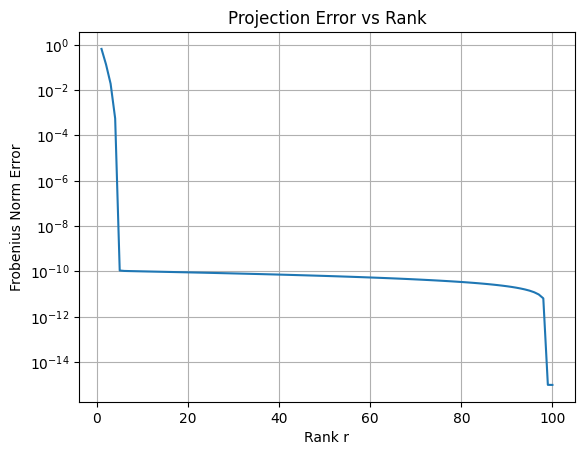

In [210]:
ranks = range(1, len(S)+1, 1)
fro_errors = []
for r in ranks:
    Ur = U[:, :r]
    P = Ur @ Ur.T
    err = np.linalg.norm((P - np.eye(P.shape[0])) @ data_centered, 'fro') / np.linalg.norm(data_centered)
    fro_errors.append(err)

plt.figure()
plt.semilogy(ranks, fro_errors)
plt.xlabel('Rank r')
plt.ylabel('Frobenius Norm Error')
plt.title('Projection Error vs Rank')
plt.grid()
plt.show()

### Trying to find the rank of the different energy threshold

In [211]:
total_energy_sq = np.sum(S**2)
cumulative_energy_sq = np.cumsum(S**2)
tail_energy_sq = total_energy_sq - cumulative_energy_sq

rel_err_fro = np.sqrt(tail_energy_sq / total_energy_sq)
missing_var_frac = tail_energy_sq / total_energy_sq
ranks_all = np.arange(1, len(S)+1)

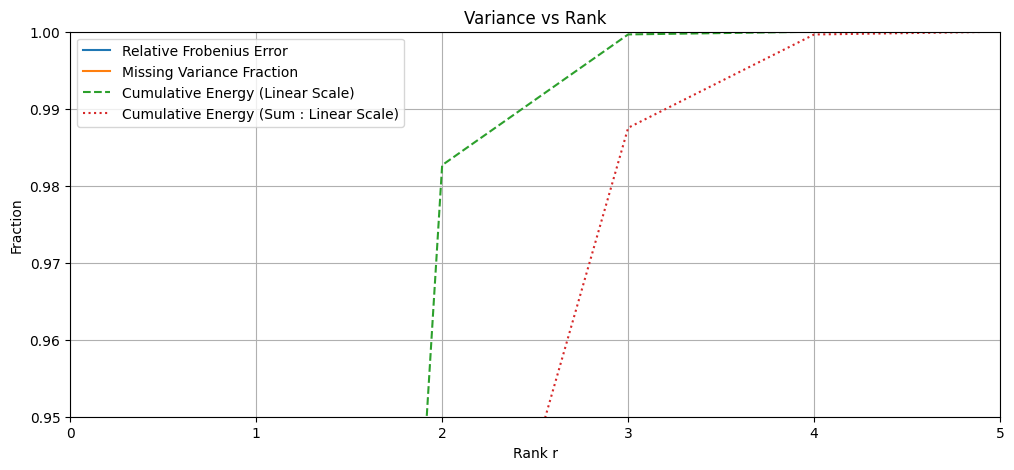

In [212]:
# plotting the variance and reconstruction error
plt.figure(figsize=(12, 5))
plt.plot(ranks_all, rel_err_fro, label='Relative Frobenius Error')
plt.plot(ranks_all, missing_var_frac, label='Missing Variance Fraction')
cum_sum_lin = np.cumsum(S) / np.sum(S)
plt.plot(ranks_all, cumulative_energy_sq / total_energy_sq,'--', label='Cumulative Energy (Linear Scale)')
plt.plot(ranks_all, cum_sum_lin,':', label='Cumulative Energy (Sum : Linear Scale)')
plt.xlabel('Rank r')
plt.ylabel('Fraction')

plt.ylim([0.95, 1])
plt.xlim([0, 5])

plt.legend()
plt.grid(True)
plt.title('Variance vs Rank')
plt.show()

In [213]:
captured_frac_sq = cumulative_energy_sq / total_energy_sq
r_99 = np.searchsorted(captured_frac_sq, 0.99) + 1
captured_fro = np.sqrt(cumulative_energy_sq) / np.sqrt(total_energy_sq)
r_fro_99 = np.searchsorted(captured_fro, 0.99) + 1
r_lin_99 = np.searchsorted(cum_sum_lin, 0.99) + 1

print(f"Rank to capture 99% variance (squared): {r_99}")
print(f"Rank to capture 99% variance (Frobenius): {r_fro_99}")
print(f"Rank to capture 99% variance (Linear sum): {r_lin_99}")

Rank to capture 99% variance (squared): 3
Rank to capture 99% variance (Frobenius): 2
Rank to capture 99% variance (Linear sum): 4


Reconstruction error (Frobenius norm) for rank 1: 0.5438726868479529
Reconstruction error (Frobenius norm) for rank 2: 0.11162194155092676
Reconstruction error (Frobenius norm) for rank 3: 0.015879940713805628
Reconstruction error (Frobenius norm) for rank 4: 0.0004697858213677234
Reconstruction error (Frobenius norm) for rank 5: 9.304344244078394e-11
Reconstruction error (Frobenius norm) for rank 10: 8.546440189588535e-11


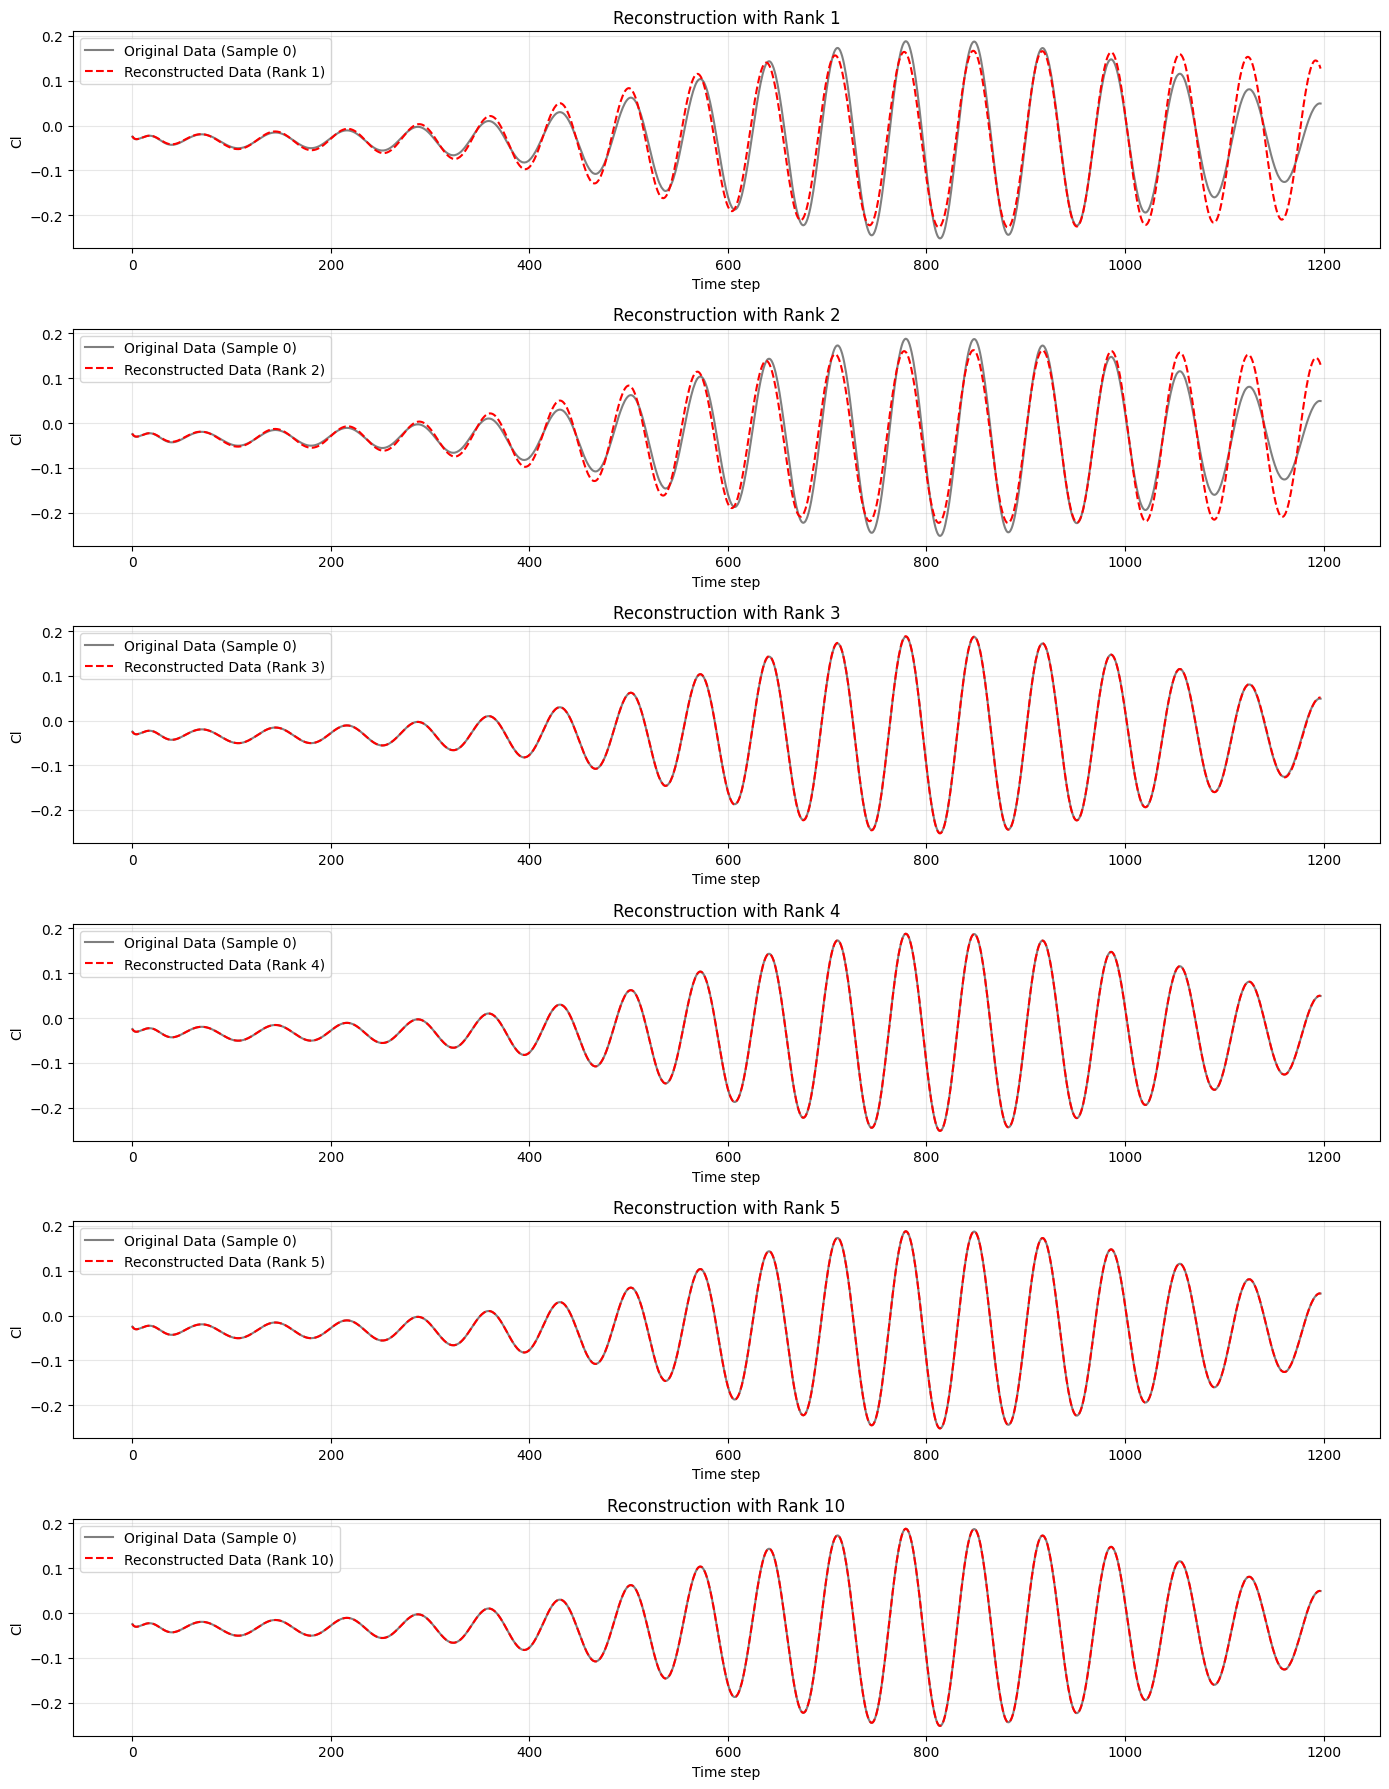

In [214]:
# Reconstructing data using different ranks
ranks_to_test = [1, 2, 3, 4, 5, 10]
reconstructions = {}
for r in ranks_to_test:
    Ur = U[:, :r]
    Sr = np.diag(S[:r])
    VTr = VT[:r, :]
    data_recon = Ur @ Sr @ VTr + data_mean
    reconstructions[r] = data_recon

for r in ranks_to_test:
    err = np.linalg.norm(data - reconstructions[r], 'fro') / np.linalg.norm(data)
    print(f"Reconstruction error (Frobenius norm) for rank {r}: {err}")
# Plotting the reconstructions
fig, axes = plt.subplots(len(ranks_to_test), 1, figsize=(14, 3*len(ranks_to_test)))
for i, r in enumerate(ranks_to_test):
    axes[i].plot(data[:, 0], 'k-', label='Original Data (Sample 0)', alpha=0.5)
    axes[i].plot(reconstructions[r][:, 0], 'r--', label=f'Reconstructed Data (Rank {r})')
    axes[i].set_title(f'Reconstruction with Rank {r}')
    axes[i].set_xlabel('Time step')
    axes[i].set_ylabel('Cl')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


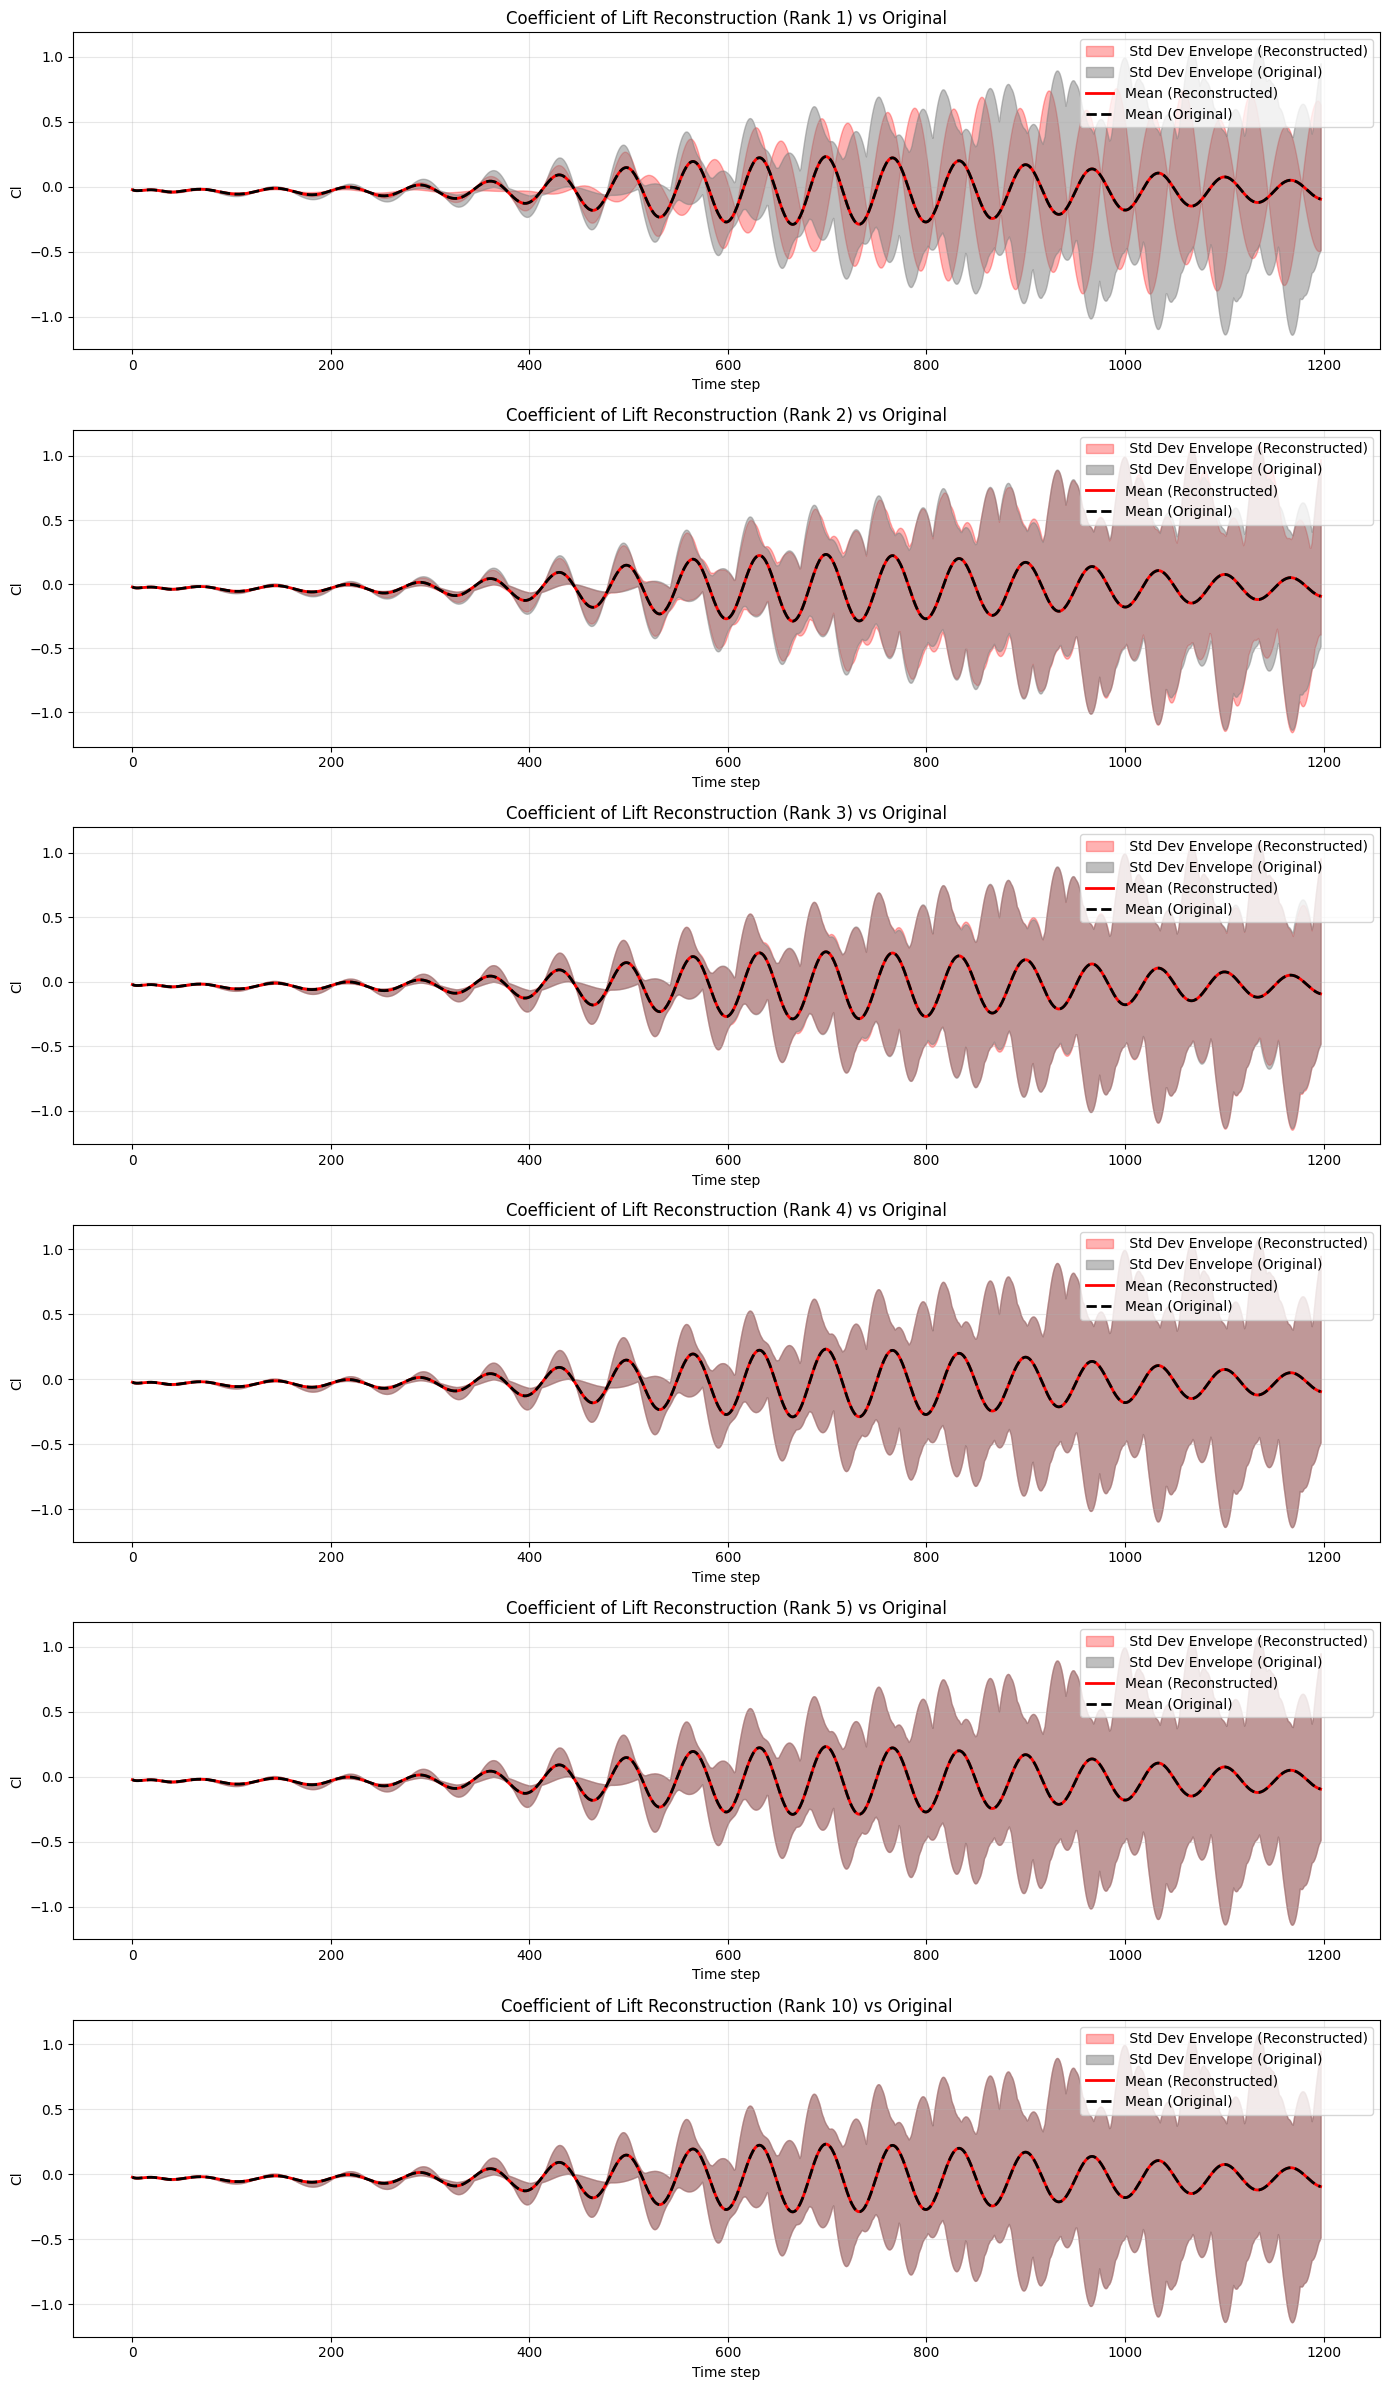

In [217]:
# To visualize a specific rank to calculate mean and std dev envelopes
r_visualize = [1,2,3,4,5,10]
# Plot original vs reconstructed statistics
fig,axes = plt.subplots(len(r_visualize), 1, figsize=(14, 24))
for i, r in enumerate(r_visualize):
    Ur = U[:, :r]
    Sr = np.diag(S[:r])
    VTr = VT[:r, :]
    data_recon = Ur @ Sr @ VTr + data_mean

    # Compute statistics for the reconstructed data
    mean_recon = data_recon.mean(axis=1)
    std_recon = data_recon.std(axis=1)
    min_recon = data_recon.min(axis=1)
    max_recon = data_recon.max(axis=1)

    axes[i].fill_between(range(1198), min_recon, max_recon, alpha=0.3, color = 'red', label = ' Std Dev Envelope (Reconstructed)')
    axes[i].fill_between(range(1198), min_cl_full, max_cl_full, alpha=0.5, color='grey', label = ' Std Dev Envelope (Original)')
    axes[i].plot(mean_recon, 'r-', linewidth=2, label='Mean (Reconstructed)')
    axes[i].plot(mean_cl_full, 'k--', linewidth=2, label='Mean (Original)')
    axes[i].set_xlabel('Time step')
    axes[i].set_ylabel('Cl')
    axes[i].set_title(f'Coefficient of Lift Reconstruction (Rank {r}) vs Original')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)  
plt.tight_layout()
plt.show()

In [218]:
# Taken from hw1_sol_new.ipynb
def randomized_svd(X, r, p=10, q=1):
    """
    Randomized SVD algorithm (Halko et al. 2011)
    
    Parameters:
    -----------
    X : ndarray of shape (n, m)
        Input matrix (typically tall-and-skinny, n >> m)
    r : int
        Target rank
    p : int, default=10
        Oversampling parameter
    q : int, default=1
        Number of power iterations
    
    Returns:
    --------
    U : ndarray of shape (n, r)
        Left singular vectors
    S : ndarray of shape (r,)
        Singular values
    Vt : ndarray of shape (r, m)
        Right singular vectors (transposed)
    """
    n, m = X.shape
    
    # Step 1: Random projection with oversampling
    # P ~ N(0, I), shape (m, r+p)
    P = np.random.randn(m, r + p)
    Z = X @ P
    
    # Power iterations to amplify singular value separation
    for _ in range(q):
        Z = X @ (X.T @ Z)
    
    # Step 2: QR factorization
    Q, R = np.linalg.qr(Z)
    
    # Step 3: Project X to lower dimension
    Y = Q.T @ X  # shape (r+p, m)
    
    # Step 4: Compute SVD of smaller matrix Y
    U_Y, s, vt = np.linalg.svd(Y, full_matrices=False)
    
    # Step 5: Recover U
    u = Q @ U_Y
    
    # Return only top r components (discard oversampling)
    return u[:, :r], s[:r], vt[:r, :]

In [ ]:
import time

target_rank = 4  

t0 = time.time()
U_full , S_full, Vt_full = np.linalg.svd(data_centered, full_matrices=False)
t_full = time.time() - t0

# Randomized SVD with different power iterations
for q in [0, 1, 2, 3, 4, 5]:
    print(f"\n--- Randomized SVD with q={q} power iterations ---")
    
    t0 = time.time()
    U_rand, S_rand, Vt_rand = randomized_svd(data_centered, target_rank, p =10, q = q)
    t_rand = time.time() - t0
    
    S_true = S_full[:target_rank]
    rel_err_S = np.linalg.norm(S_rand - S_true) / np.linalg.norm(S_true)

    # Reconstruct
    data_approx_full = U_full[:, :target_rank] @ np.diag(S_full[:target_rank]) @ Vt_full[:target_rank, :] + data_mean
    data_rand = U_rand @ np.diag(S_rand) @ Vt_rand + data_mean

    recon_err_full = np.linalg.norm(data_approx_full - data_centered - data_mean, 'fro') / np.linalg.norm(data_centered)
    recon_err_rand = np.linalg.norm(data_rand - data_centered - data_mean, 'fro') / np.linalg.norm(data_centered)

    print(f"\nPower iterations q={q}:")    
    print(f"Time: {t_rand:.4f} seconds (speedup vs full: {t_full / t_rand:.2f}x)")
    print(f"Singular value error: {rel_err_S:.2e}")
    print(f"Reconstruction error (full SVD): {recon_err_full:.2e}")
    print(f"Reconstruction error (randomized SVD): {recon_err_rand:.2e}")
    




--- Randomized SVD with q=0 power iterations ---

Power iterations q=0:
Time: 0.0183 seconds (speedup vs full: 29.19x)
Singular value error: 5.59e-16
Reconstruction error (full SVD): 5.54e-04
Reconstruction error (randomized SVD): 5.54e-04

--- Randomized SVD with q=1 power iterations ---

Power iterations q=1:
Time: 0.0113 seconds (speedup vs full: 47.31x)
Singular value error: 3.63e-16
Reconstruction error (full SVD): 5.54e-04
Reconstruction error (randomized SVD): 5.54e-04

--- Randomized SVD with q=2 power iterations ---

Power iterations q=2:
Time: 0.0073 seconds (speedup vs full: 73.34x)
Singular value error: 3.33e-16
Reconstruction error (full SVD): 5.54e-04
Reconstruction error (randomized SVD): 5.54e-04

--- Randomized SVD with q=3 power iterations ---

Power iterations q=3:
Time: 0.0034 seconds (speedup vs full: 156.60x)
Singular value error: 1.53e-12
Reconstruction error (full SVD): 5.54e-04
Reconstruction error (randomized SVD): 5.54e-04

--- Randomized SVD with q=4 power 

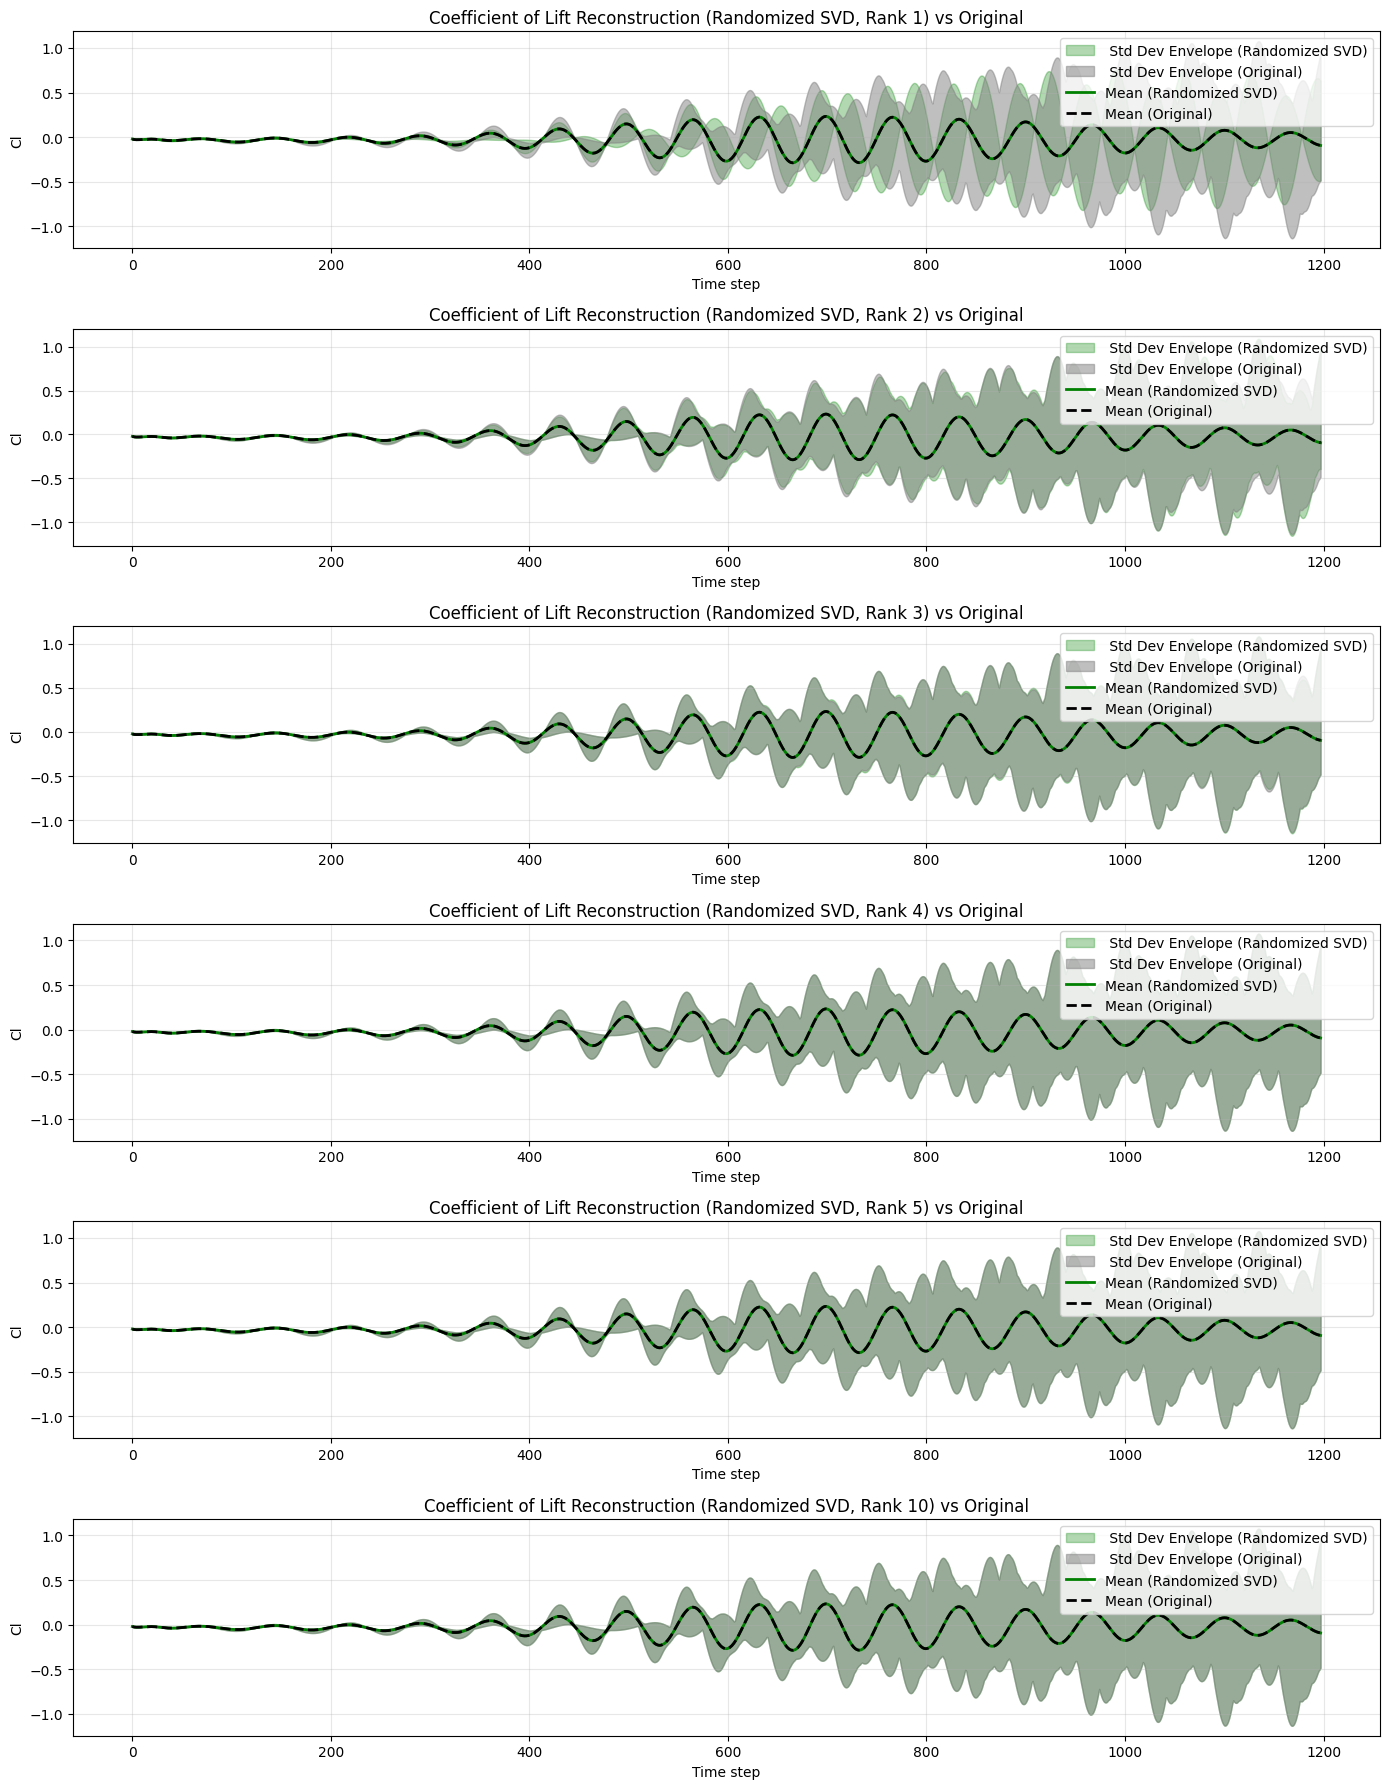

In [225]:
# Reconctruction using randomized SVD
r_targets = [1,2,3,4,5,10]
fig,axes = plt.subplots(len(r_targets), 1, figsize=(14, 3*len(r_targets))) 
for i,r in enumerate(r_targets):
    U_rand, S_rand, Vt_rand = randomized_svd(data_centered, r, p=10, q=2)

    data_rand = U_rand @ np.diag(S_rand) @ Vt_rand + data_mean

    rand_mean = data_rand.mean(axis=1)
    rand_std = data_rand.std(axis=1)
    rand_min = data_rand.min(axis=1)
    rand_max = data_rand.max(axis=1)

    axes[i].fill_between(range(1198), rand_min, rand_max, alpha=0.3, color = 'green', label = ' Std Dev Envelope (Randomized SVD)')
    axes[i].fill_between(range(1198), min_cl_full, max_cl_full, alpha=0.5, color='grey', label = ' Std Dev Envelope (Original)')
    axes[i].plot(rand_mean, 'g-', linewidth=2, label='Mean (Randomized SVD)')
    axes[i].plot(mean_cl_full, 'k--', linewidth=2, label='Mean (Original)') 
    axes[i].set_xlabel('Time step')
    axes[i].set_ylabel('Cl')
    axes[i].set_title(f'Coefficient of Lift Reconstruction (Randomized SVD, Rank {r}) vs Original')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)  
plt.tight_layout()
plt.show()